In [3]:
from isofit.core.fileio import IO
from isofit.core.forward import ForwardModel
from isofit.inversion.inverse import Inversion
from isofit.inversion.inverse_simple import invert_algebraic, invert_simple
from isofit.configs import configs
from isofit.core.geometry import Geometry

import os
from glob import glob
import logging
import numpy as np
from spectral.io import envi
from spectral.io.envi import read_envi_header
import matplotlib.pyplot as plt

import pickle

from utilities import single_px_retrieval

# %matplotlib widget

# Enable the ISOFIT logger
logging.getLogger().setLevel(logging.INFO)

In [10]:
# exploratory single-pixel retrievals for iterative improvements

# single pixels are mean rdn values over representative pixels of each of the three classes:
# white tarp, black tarp, aspen

# for cal tarps, get them in all of the relevant flight lines

In [4]:
# define file paths
home = '/store/carroll/col/2018/'
aspen = home+'test_roi/aspen/'
cal = home+'test_roi/calTarp/'

In [5]:
cal_flightlines = [x.split('/')[-1].strip('_rdn') for x in glob(cal + f'subset/*_rdn')]
cal_flightlines

['NIS01_20180611_172310',
 'NIS01_20180611_172711',
 'NIS01_20180611_173116',
 'NIS01_20180611_173537']

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07828101..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.078737326..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.083023794..2.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.07466234..2.0].


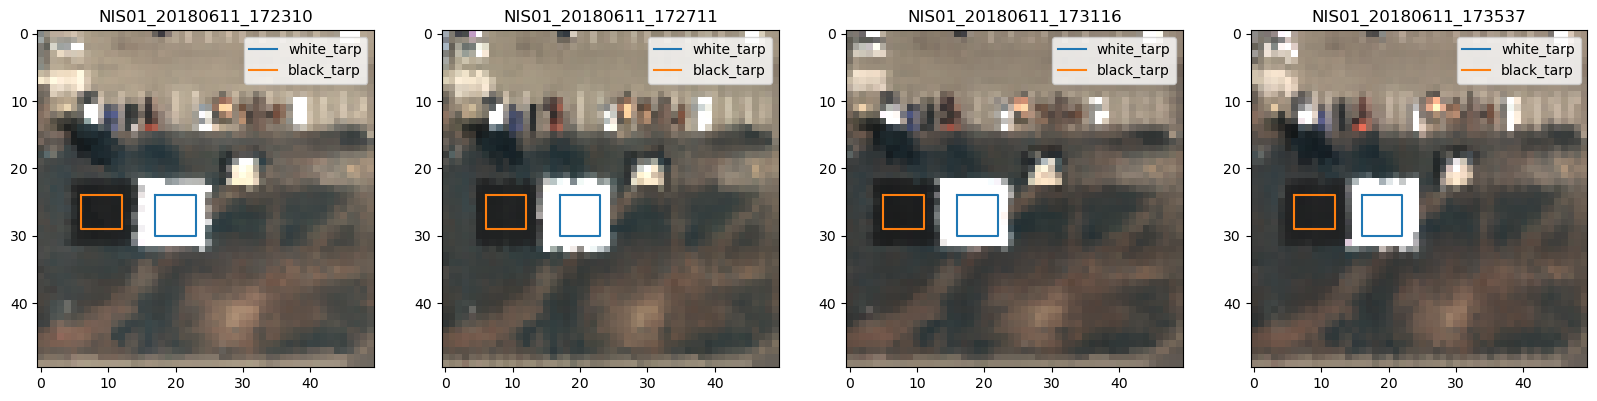

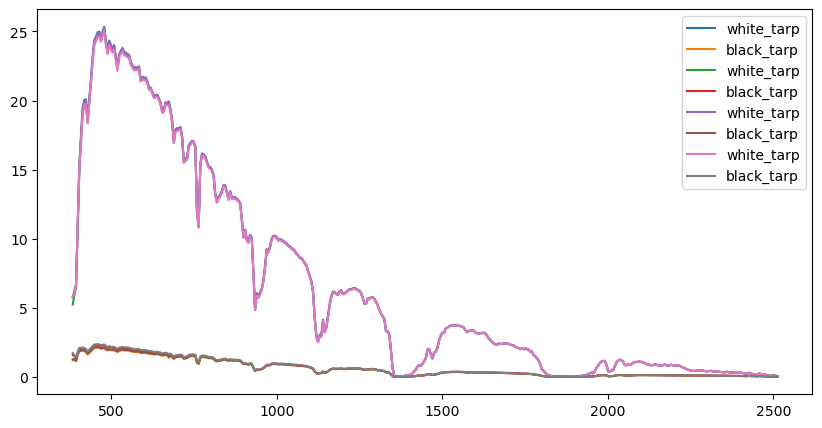

In [6]:
# cal tarps

cal_flightlines = [x.split('/')[-1].strip('_rdn') for x in glob(cal + f'subset/*_rdn')]
n_flights = len(cal_flightlines)
tarps = ['white_tarp', 'black_tarp']

# prepare representative single pixels
rdn = {k: {} for k in cal_flightlines}
obs = {k: {} for k in cal_flightlines}
loc = {k: {} for k in cal_flightlines}
bboxes = {k: {} for k in cal_flightlines}

# define bboxes per flightline
bboxes['NIS01_20180611_172310']['white_tarp'] = [17,24,23,30]
bboxes['NIS01_20180611_172310']['black_tarp'] = [6,24,12,29]

bboxes['NIS01_20180611_172711']['white_tarp'] = [17,24,23,30]
bboxes['NIS01_20180611_172711']['black_tarp'] = [6,24,12,29]

bboxes['NIS01_20180611_173116']['white_tarp'] = [16,24,22,30]
bboxes['NIS01_20180611_173116']['black_tarp'] = [5,24,11,29]

bboxes['NIS01_20180611_173537']['white_tarp'] = [16,24,22,30]
bboxes['NIS01_20180611_173537']['black_tarp'] = [6,24,12,29]

# cal tarps
fig, axs = plt.subplots(ncols=n_flights, figsize=(5*n_flights, 5))
for i in range(n_flights):
    flight = cal_flightlines[i]
    for k in tarps:
        minx, miny, maxx, maxy = bboxes[flight][k]
        fp = glob(os.path.join(cal, 'subset', f'{flight}_rdn.hdr'))[0]
        rdn[flight][k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
        fp = glob(os.path.join(cal, 'subset', f'{flight}_obs.hdr'))[0]
        obs[flight][k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
        fp = glob(os.path.join(cal, 'subset', f'{flight}_igm.hdr'))[0]
        loc[flight][k] = np.nanmean(envi.open(fp).open_memmap(interleave='bip')[miny:maxy, minx:maxx, :], axis=(0,1))
    
    fp = glob(os.path.join(cal, 'subset', f'{flight}_rdn.hdr'))[0]
    wl = [float(x) for x in read_envi_header(fp)['wavelength']]
    rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
    axs[i].imshow(rgb / np.max(rgb, axis=(0, 1))*2)
    for k, (minx, miny, maxx, maxy) in bboxes[flight].items():
        x = [minx, maxx, maxx, minx, minx]
        y = [miny, miny, maxy, maxy, miny]
        axs[i].plot(x, y, label=k)
    axs[i].legend()
    axs[i].set_title(flight)
plt.show()

# plot radiance

fig = plt.figure(figsize=(10,5))
for f in cal_flightlines:
    for k in ['white_tarp', 'black_tarp']:
        plt.plot(wl, rdn[f][k], label=k)
plt.legend()
plt.show()

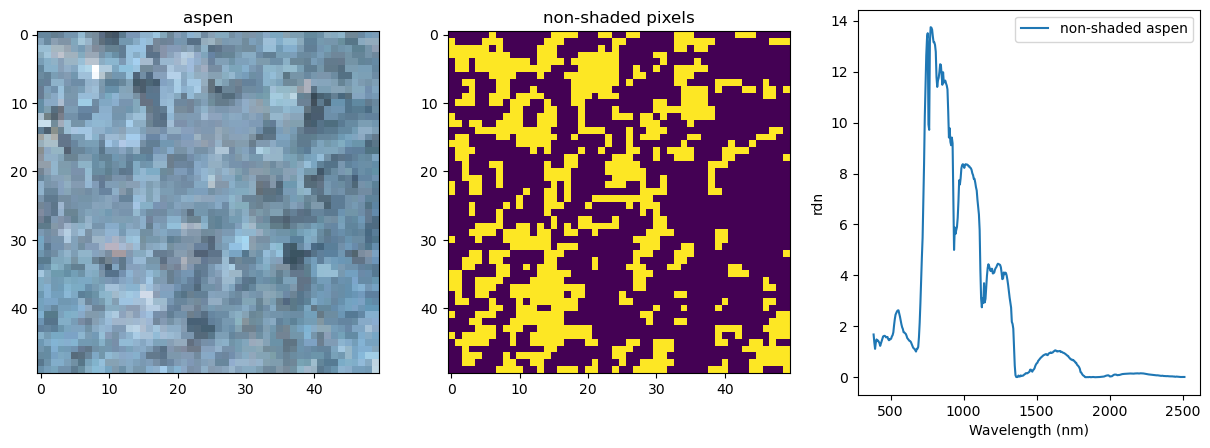

In [7]:
# aspen

flight = 'NIS01_20180619_172934'
rdn[flight] = {}
obs[flight] = {}
loc[flight] = {}

k = 'aspen'
fp = glob(os.path.join(home, 'test_roi', k, 'subset', '*_rdn.hdr'))[0]
tmp = envi.open(fp).open_memmap(interleave='bip').copy()
shaded = np.sum(tmp[...,[60,40,30]], axis=2) < 5
tmp[shaded, :] = np.nan
rdn[flight][k] = np.nanmean(tmp, axis=(0,1))
fp = glob(os.path.join(home, 'test_roi', k, 'subset', '*_obs.hdr'))[0]
tmp  = envi.open(fp).open_memmap(interleave='bip').copy()
tmp[shaded, :] = np.nan
obs[flight][k] = np.nanmean(tmp, axis=(0,1))
fp = glob(os.path.join(home, 'test_roi', k, 'subset', '*_igm.hdr'))[0]
tmp  = envi.open(fp).open_memmap(interleave='bip').copy()
tmp[shaded, :] = np.nan
loc[flight][k] = np.nanmean(tmp, axis=(0,1))

fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
fp = glob(os.path.join(home, 'test_roi', k, 'subset', '*_rdn.hdr'))[0]
rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
axs[0].imshow(rgb / np.max(rgb, axis=(0, 1)))
axs[0].set_title(k)
lit = np.sum(rgb, axis=2)
valid = lit > 5
axs[1].imshow(valid)
axs[1].set_title('non-shaded pixels')
axs[2].plot(wl, rdn[flight][k], label='non-shaded aspen')
axs[2].legend()
axs[2].set_xlabel('Wavelength (nm)')
axs[2].set_ylabel('rdn')
plt.show()

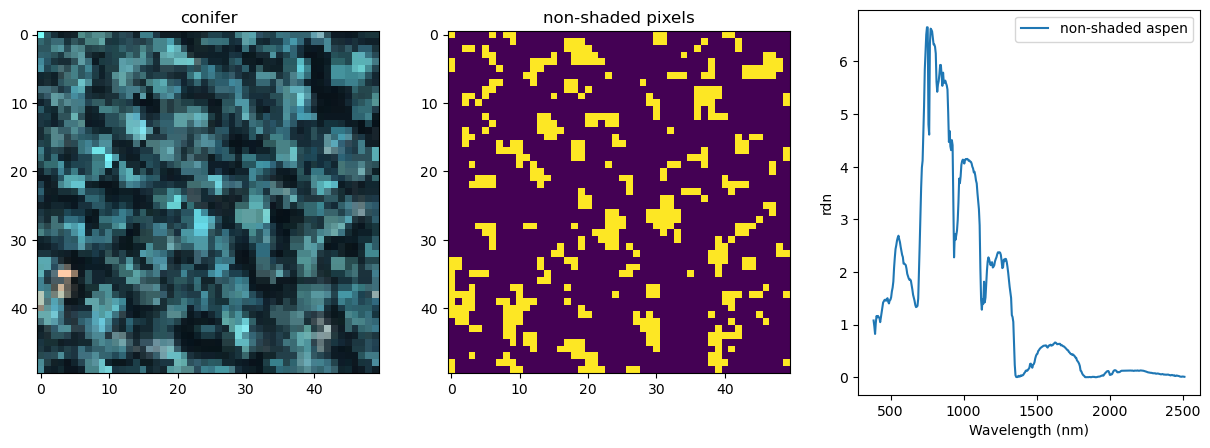

In [8]:
# conifer

flight = 'NIS01_20180619_160339'
rdn[flight] = {}
obs[flight] = {}
loc[flight] = {}

k = 'conifer'
fp = glob(os.path.join(home, 'test_roi', k, 'subset', '*_rdn.hdr'))[0]
tmp = envi.open(fp).open_memmap(interleave='bip').copy()
shaded = np.sum(tmp[...,[60,40,30]], axis=2) < 5
tmp[shaded, :] = np.nan
rdn[flight][k] = np.nanmean(tmp, axis=(0,1))
fp = glob(os.path.join(home, 'test_roi', k, 'subset', '*_obs.hdr'))[0]
tmp  = envi.open(fp).open_memmap(interleave='bip').copy()
tmp[shaded, :] = np.nan
obs[flight][k] = np.nanmean(tmp, axis=(0,1))
fp = glob(os.path.join(home, 'test_roi', k, 'subset', '*_igm.hdr'))[0]
tmp  = envi.open(fp).open_memmap(interleave='bip').copy()
tmp[shaded, :] = np.nan
loc[flight][k] = np.nanmean(tmp, axis=(0,1))

fig, axs = plt.subplots(ncols=3, figsize=(15, 5))
fp = glob(os.path.join(home, 'test_roi', k, 'subset', '*_rdn.hdr'))[0]
rgb = envi.open(fp).open_memmap(interleave='bip')[:,:,np.array([60,40,30])].copy()
axs[0].imshow(rgb / np.max(rgb, axis=(0, 1)))
axs[0].set_title(k)
lit = np.sum(rgb, axis=2)
valid = lit > 5
axs[1].imshow(valid)
axs[1].set_title('non-shaded pixels')
axs[2].plot(wl, rdn[flight][k], label='non-shaded aspen')
axs[2].legend()
axs[2].set_xlabel('Wavelength (nm)')
axs[2].set_ylabel('rdn')
plt.show()

In [12]:
out = {
    'rdn':rdn,
    'obs':obs,
    'loc':loc,
    'bboxes': bboxes
}
with open('/store/carroll/col/2018/test_roi/single_pxs.pkl', 'wb') as f:
    pickle.dump(out, f)

In [13]:
with open('/store/carroll/col/2018/test_roi/single_pxs.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)

In [17]:
loaded_dict['loc'][flight]['conifer'][2]

3311.4061546480784